In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, FunctionTransformer
import xgboost as xgb

from modules import *
dataset_path = './data/dataset.csv'

pipACE = PIACEIngestionPipeline(freq_minutes=5)
fe = PIACEFeatureEngineering(config_path='config/moduledb.json')
vis = DatasetVisualizer(config_path='config/moduledb.json')

import joblib
pipeline = joblib.load("./model/full_pipeline_model.pkl")

_RANDOM_SEED = 42
np.random.seed(_RANDOM_SEED)

In [7]:
# Cargar el dataset original
df_raw = pipACE.load_data(dataset_path)

In [8]:
# Resamplear y alinear todas las 46 señales a la grilla de 5 minutos de Time_CNA
df_resampled = pipACE.process_tag_series(df_raw, reference_time_col='Time_CNA', include_quality_flags=True)

# Separar variables predictoras (X) y variable objetivo (y: estado Calc Failed)
X = df_resampled.drop(columns=['CNA', 'CNA_Has_Bad'])
# 1 si CNA tuvo error o fue nulo, 0 si fue cálculo normal
y = ((df_resampled['CNA_Has_Bad'] == 1) | (df_resampled['CNA'].isna())).astype(int)

print("Dimensiones tras resampleo:", X.shape)

Dimensiones tras resampleo: (8641, 90)


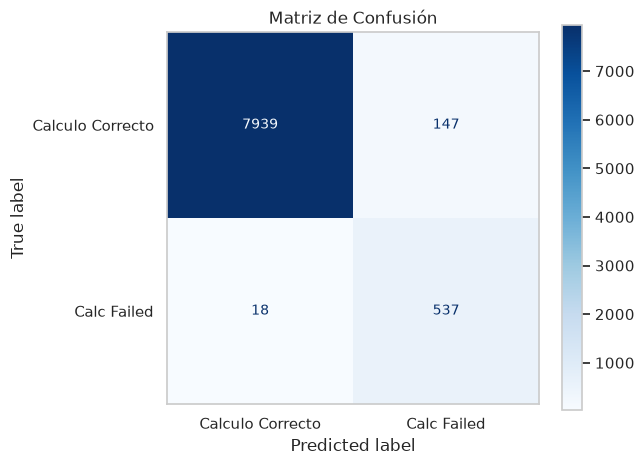


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      8086
           1       0.79      0.97      0.87       555

    accuracy                           0.98      8641
   macro avg       0.89      0.97      0.93      8641
weighted avg       0.98      0.98      0.98      8641



In [9]:
# Generar predicciones sobre el conjunto de prueba
y_pred = pipeline.predict(X)

# Matriz de confusion
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Calculo Correcto', 'Calc Failed'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión')
plt.grid(False)
plt.show()

print("\n--- Reporte de Clasificación ---")
print(classification_report(y, y_pred))

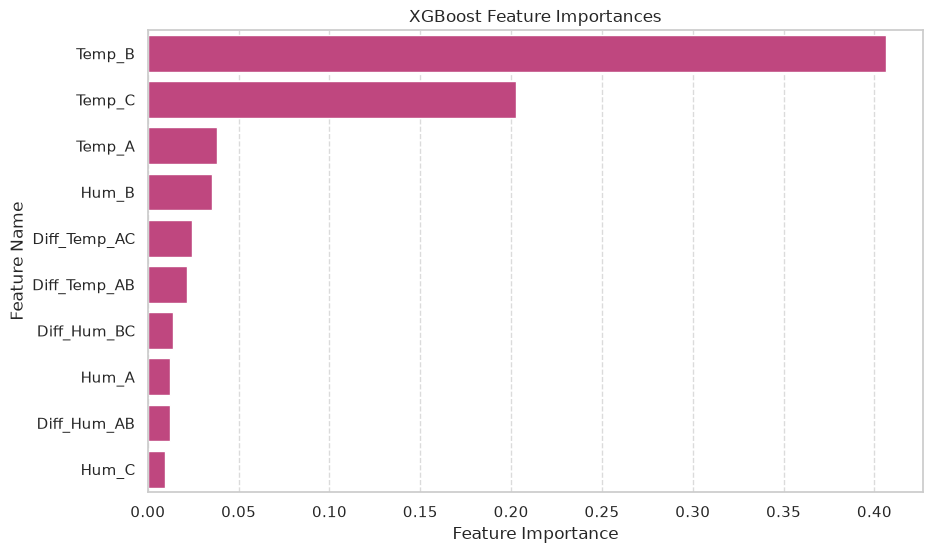

In [10]:
# Feature Importance Plot
# XGBoost has a built-in function to get feature importances
xgb_step = pipeline.named_steps['classifier']
feature_importances = xgb_step.feature_importances_
X_train_transformed = pipeline.named_steps['feature_engineering'].transform(X)
feature_names = X_train_transformed.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df[0:10], color="#d3337e")
plt.xlabel("Feature Importance")
plt.ylabel("Feature Name")
plt.title("XGBoost Feature Importances")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()